### 1-Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

### 2-Read Data

In [2]:
df = pd.read_csv('4910797b-ee55-40a7-8668-10efd5c1b960.csv').merge(pd.read_csv('0bf8bc6e-30d0-4c50-956a-603fc693d966.csv'), on='id')
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

There is alot of unnecessary and repeated columns, we will use only strong ones.

### 3-Data Understanding

In [4]:
(df.isna().mean()*100).sort_values(ascending=False)

scheme_name              48.501684
scheme_management         6.528620
installer                 6.153199
funder                    6.122896
public_meeting            5.612795
permit                    5.144781
subvillage                0.624579
wpt_name                  0.003367
id                        0.000000
latitude                  0.000000
longitude                 0.000000
date_recorded             0.000000
gps_height                0.000000
amount_tsh                0.000000
num_private               0.000000
basin                     0.000000
region                    0.000000
ward                      0.000000
lga                       0.000000
district_code             0.000000
region_code               0.000000
recorded_by               0.000000
population                0.000000
construction_year         0.000000
extraction_type           0.000000
extraction_type_group     0.000000
extraction_type_class     0.000000
management                0.000000
management_group    

scheme_name column has ~50% NaN, so it will be dropped. Other columns has more than 5% NaN so they must be cleaned

In [5]:
df.describe(include='object')

,date_recorded,funder,installer,wpt_name,basin,subvillage,region,lga,ward,public_meeting,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
count,59400,55763,55745,59398,59400,59029,59400,59400,59400,56066,...,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400
unique,356,1896,2145,37399,9,19287,21,125,2092,2,...,8,6,5,5,10,7,3,7,6,3
top,2011-03-15,Government Of Tanzania,DWE,none,Lake Victoria,Madukani,Iringa,Njombe,Igosi,True,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
freq,572,9084,17402,3563,10248,508,5294,2503,307,51011,...,50818,50818,33186,33186,17021,17021,45794,28522,34625,32259


In [6]:
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [7]:
df = df.drop_duplicates()

In [8]:
strong_predictors = [
    'quantity', 'waterpoint_type', 'extraction_type_class',
    'construction_year', 'payment', 'water_quality', 'source',
    'gps_height', 'longitude', 'latitude', 'population',
    'management', 'funder', 'installer', 'date_recorded',
    'permit', 'public_meeting', 'amount_tsh'
]

df_training = df[strong_predictors + ['status_group']].copy()
df_training.shape

(59400, 19)

### 4-Data Cleaning

In [9]:
(df_training.isna().mean()*100).sort_values(ascending=False)

installer                6.153199
funder                   6.122896
public_meeting           5.612795
permit                   5.144781
extraction_type_class    0.000000
quantity                 0.000000
waterpoint_type          0.000000
construction_year        0.000000
payment                  0.000000
water_quality            0.000000
source                   0.000000
population               0.000000
latitude                 0.000000
longitude                0.000000
gps_height               0.000000
date_recorded            0.000000
management               0.000000
amount_tsh               0.000000
status_group             0.000000
dtype: float64

In [10]:
df_training.installer.value_counts().index.tolist()

['DWE',
 'Government',
 'RWE',
 'Commu',
 'DANIDA',
 'KKKT',
 'Hesawa',
 '0',
 'TCRS',
 'Central government',
 'CES',
 'Community',
 'DANID',
 'District Council',
 'HESAWA',
 'LGA',
 'World vision',
 'WEDECO',
 'TASAF',
 'District council',
 'Gover',
 'AMREF',
 'TWESA',
 'WU',
 'Dmdd',
 'ACRA',
 'World Vision',
 'SEMA',
 'DW',
 'OXFAM',
 'Da',
 'Idara ya maji',
 'Gove',
 'UNICEF',
 'Sengerema Water Department',
 'Kiliwater',
 'FinW',
 'NORAD',
 'DH',
 'Villagers',
 'DWSP',
 'Distri',
 'Lawatefuka water sup',
 'Magadini-Makiwaru wa',
 'RC',
 'FW',
 'KKKT _ Konde and DWE',
 'Centr',
 'WVT',
 'MWE',
 'Handeni Trunk Main(',
 'Is',
 'Norad',
 'RWSSP',
 'Fini Water',
 'SHIPO',
 'Private',
 'Kuwait',
 'JAICA',
 'Central govt',
 'ISF',
 'Artisan',
 'Fini water',
 'GOVER',
 'DDCA',
 'HE',
 'RC CHURCH',
 'Tardo',
 'World',
 'Mission',
 'wananchi',
 'Ir',
 'Consulting Engineer',
 'Amref',
 'JICA',
 'TWE',
 'Central Government',
 'MUWSA',
 'DED',
 'FINI WATER',
 'WATER AID',
 'Halmashauri ya wilay

funder and installer columns need string stripping and lowering

In [11]:
for col in ['funder', 'installer']:
    df_training[col] = (df_training[col]
                        .str.strip()
                        .str.lower()
                        .str.replace(r'\s+', ' ', regex=True))

In [12]:
numeric_cols=df_training.select_dtypes(include='number').columns
(df_training[numeric_cols] == 0).sum().sort_values(ascending=False)

amount_tsh           41639
population           21381
construction_year    20709
gps_height           20438
longitude             1812
latitude                 0
dtype: int64

In [13]:
non_numeric_cols = df_training.select_dtypes(include='object').columns
(df_training[non_numeric_cols] == 'unknown').sum().sort_values(ascending=False)

payment                  8157
water_quality            1876
quantity                  789
management                561
source                     66
funder                      4
installer                   4
waterpoint_type             0
extraction_type_class       0
date_recorded               0
permit                      0
public_meeting              0
status_group                0
dtype: int64

Most of the values in these columns are zeros and unknowns, so we will use imputers to fill them

In [14]:
df_training['date_recorded'] = pd.to_datetime(df_training['date_recorded'])


In [15]:
zeros_numeric_cols=[col for col in df_training[numeric_cols] if ((df_training[col]==0).sum())>0]
unknown_non_numeric_cols=[col for col in df_training[non_numeric_cols] if ((df_training[col]=='unknown').sum())>0]

In [16]:
unknown_non_numeric_cols

['quantity',
 'payment',
 'water_quality',
 'source',
 'management',
 'funder',
 'installer']

In [17]:
for col in zeros_numeric_cols:
    df_training[col]=np.where(df_training[col]==0,np.nan,df_training[col])
for col in unknown_non_numeric_cols:
    df_training[col]=np.where(df_training[col]=='unknown',np.nan,df_training[col])

In [18]:
(df_training.isna().mean()*100).sort_values(ascending=False)

amount_tsh               70.099327
population               35.994949
construction_year        34.863636
gps_height               34.407407
payment                  13.732323
installer                 6.159933
funder                    6.129630
public_meeting            5.612795
permit                    5.144781
water_quality             3.158249
longitude                 3.050505
quantity                  1.328283
management                0.944444
source                    0.111111
waterpoint_type           0.000000
extraction_type_class     0.000000
latitude                  0.000000
date_recorded             0.000000
status_group              0.000000
dtype: float64

### 5-EDA

<Axes: title={'center': 'amount_tsh'}, xlabel='installer'>

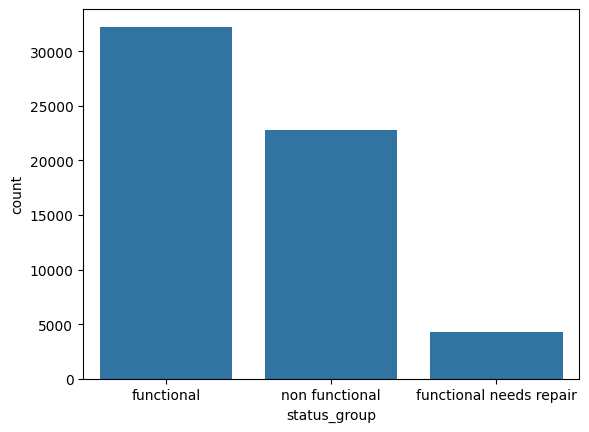

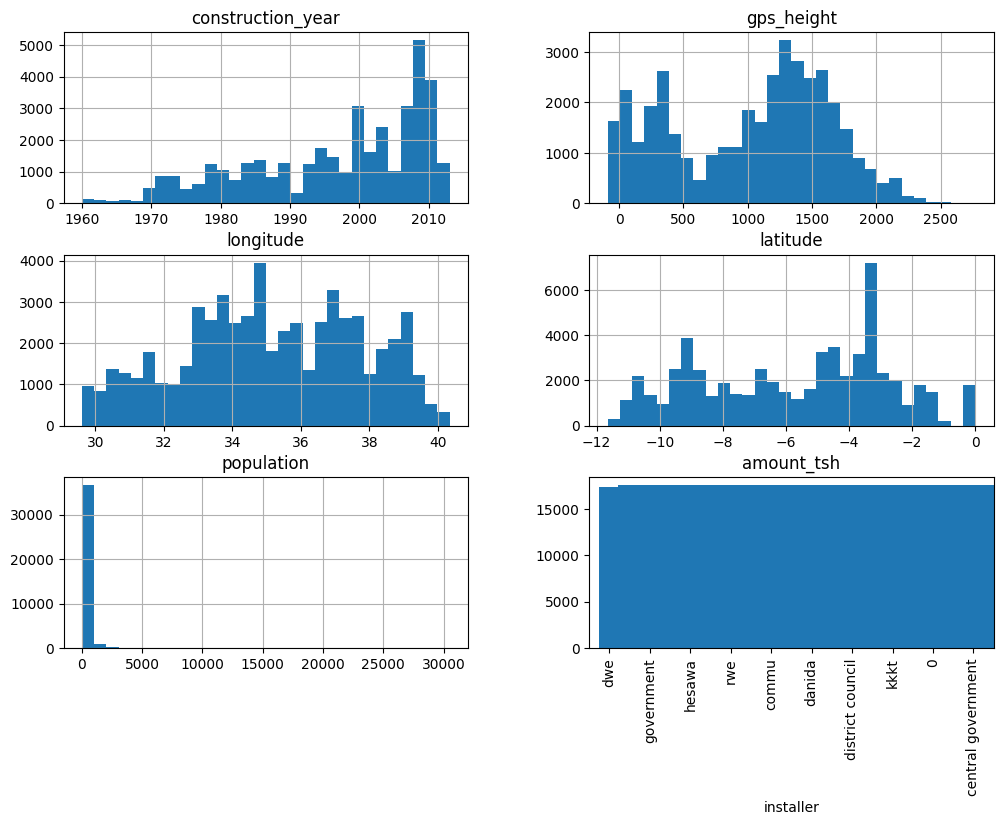

In [19]:
# 1. Target distribution — always first
sns.countplot(data=df_training, x='status_group')

# 2. Numeric distributions
df_training[numeric_cols].hist(figsize=(12,8), bins=30)

# 3. Top categories for high-cardinality cols
df_training['installer'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='quantity', ylabel='count'>

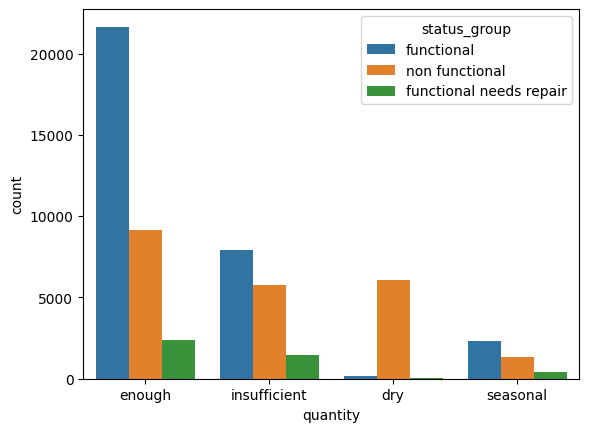

In [20]:
# 4. Most important feature vs target
sns.countplot(data=df_training, x='quantity', hue='status_group')

# # 5. Age vs status
# sns.boxplot(data=df_training, x='status_group', y=df_training['date_recorded'].dt.year - df_training['construction_year'])

# # 6. Payment vs status
# sns.countplot(data=df_training, x='payment', hue='status_group')

# # 7. Water quality vs status
# sns.countplot(data=df_training, x='water_quality', hue='status_group')

<Axes: xlabel='status_group', ylabel='None'>

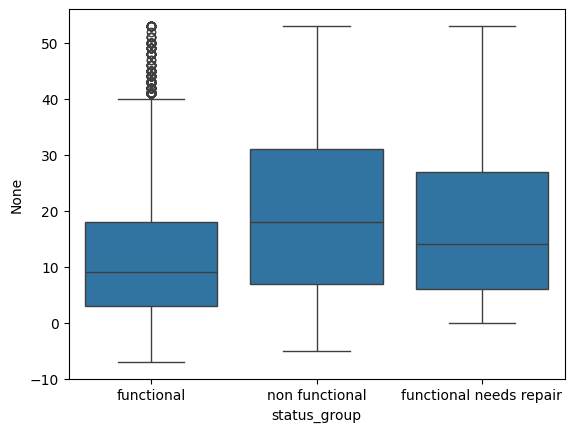

In [21]:
# 5. Age vs status
sns.boxplot(data=df_training, x='status_group', y=df_training['date_recorded'].dt.year - df_training['construction_year'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14840\2625958361.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, 'pay annually'),
 Text(1, 0, 'never pay'),
 Text(2, 0, 'pay per bucket'),
 Text(3, 0, 'pay when scheme fails'),
 Text(4, 0, 'other'),
 Text(5, 0, 'pay monthly')]

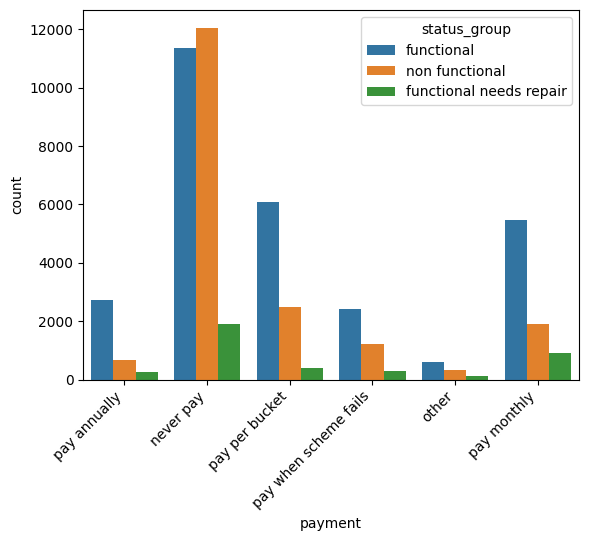

In [22]:
# 6. Payment vs status
ax = sns.countplot(data=df_training, x='payment', hue='status_group')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14840\3221608592.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, 'soft'),
 Text(1, 0, 'salty'),
 Text(2, 0, 'milky'),
 Text(3, 0, 'fluoride'),
 Text(4, 0, 'coloured'),
 Text(5, 0, 'salty abandoned'),
 Text(6, 0, 'fluoride abandoned')]

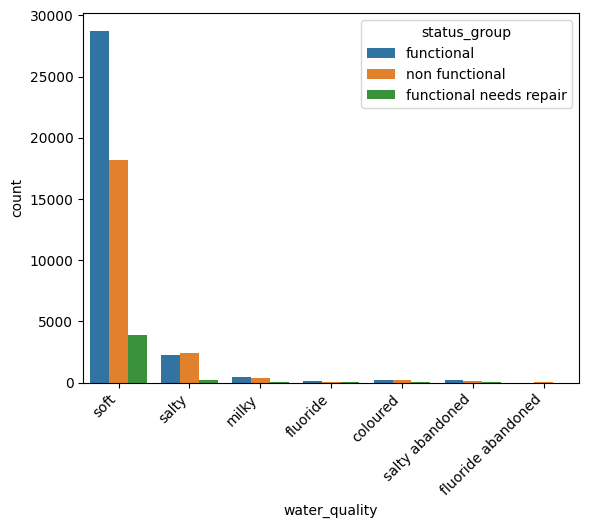

In [23]:
# 7. Water quality vs status
ax = sns.countplot(data=df_training, x='water_quality', hue='status_group')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

<Axes: xlabel='longitude', ylabel='latitude'>

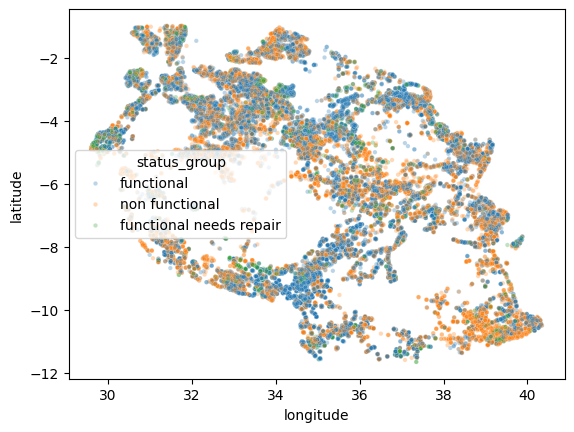

In [24]:
# 8. Map of pump locations colored by status
sns.scatterplot(data=df_training, x='longitude', y='latitude',
                hue='status_group', alpha=0.3, s=10)

<Axes: >

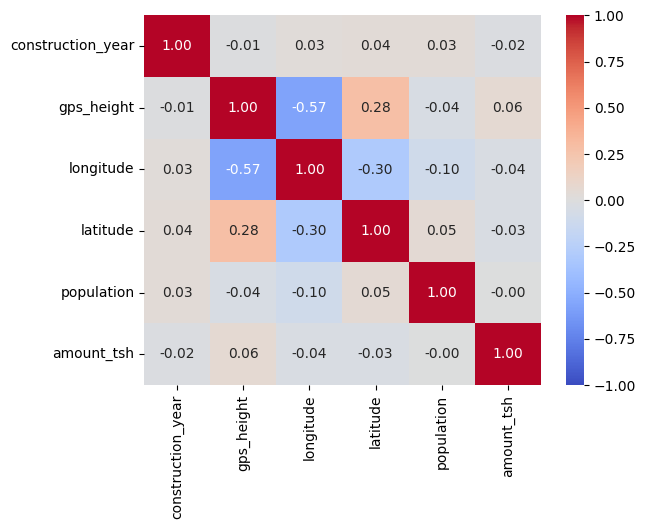

In [25]:
# 9. Numeric correlations
sns.heatmap(df_training[numeric_cols].corr(), annot=True, fmt='.2f', vmin=-1,vmax=1,cmap='coolwarm')

### 6-Data Splitting

In [26]:
X=df_training.drop(columns='status_group')
y=df_training['status_group']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

from sklearn.impute import SimpleImputer
cat_cols = [c for c in non_numeric_cols if c != 'status_group']
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

### 7-Feature Engineering

In [28]:
# from sklearn.cluster import KMeans

# coords = ['longitude', 'latitude']

# kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
# X_train['zone'] = kmeans.fit_predict(X_train[coords])
# X_test['zone'] = kmeans.predict(X_test[coords])

# X_train = X_train.drop(columns=coords)
# X_test = X_test.drop(columns=coords)
# zone_names = {
#     0: 'Lake Victoria',
#     1: 'Northern',
#     2: 'Coastal',
#     3: 'Central',
#     4: 'Southern Highlands',
#     5: 'Western',
#     6: 'Southern',
#     7: 'Kilimanjaro',
# }

# X_train['zone'] = X_train['zone'].map(zone_names)
# X_test['zone'] = X_test['zone'].map(zone_names)

In [29]:
import reverse_geocoder as rg

coords = list(zip(X_train['latitude'], X_train['longitude']))
results = rg.search(coords, mode=1)

X_train['zone'] = [r['admin1'] for r in results]

coords_test = list(zip(X_test['latitude'], X_test['longitude']))
results_test = rg.search(coords_test, mode=1)
X_test['zone'] = [r['admin1'] for r in results_test]

X_train = X_train.drop(columns=['longitude', 'latitude'])
X_test  = X_test.drop(columns=['longitude', 'latitude'])

zone_names = X_train['zone'].unique().tolist()


Loading formatted geocoded file...


In [30]:
def add_features(X):
    X = X.copy()
    X['age'] = X['date_recorded'].dt.year - X['construction_year']
    X['age'] = X['age'].clip(lower=0)
    return X

X_train = add_features(X_train)
X_test = add_features(X_test)

In [31]:
X_train = X_train.drop(columns=['date_recorded', 'construction_year'])
X_test = X_test.drop(columns=['date_recorded', 'construction_year'])

In [32]:
top = X_train["funder"].value_counts().nlargest(10).index
X_train["funder"] = X_train["funder"].where(X_train["funder"].isin(top), 'other')
X_test["funder"] = X_test["funder"].where(X_test["funder"].isin(top), 'other')

In [33]:
top = X_train["installer"].value_counts().nlargest(10).index
X_train["installer"] = X_train["installer"].where(X_train["installer"].isin(top), 'other')
X_test["installer"] = X_test["installer"].where(X_test["installer"].isin(top), 'other')

In [34]:
X_train.permit=X_train.permit.astype('int')
X_train.public_meeting=X_train.public_meeting.astype('int')
X_test.permit=X_test.permit.astype('int')
X_test.public_meeting=X_test.public_meeting.astype('int')

In [35]:
X_train.reset_index(inplace=True)

In [36]:
X_test.reset_index(inplace=True)

In [37]:
X_train = X_train.drop(columns=X_train.columns[0])


In [38]:
X_test = X_test.drop(columns=X_test.columns[0])

In [39]:
X_train.head()

,quantity,waterpoint_type,extraction_type_class,payment,water_quality,source,gps_height,population,management,funder,installer,permit,public_meeting,amount_tsh,zone,age
0,insufficient,communal standpipe,gravity,never pay,soft,spring,1167.0,150.0,vwc,government of tanzania,dwe,1,1,250.0,Mbeya,11.0
1,enough,communal standpipe,gravity,pay monthly,soft,spring,2049.0,175.0,wua,other,other,1,1,500.0,Njombe,3.0
2,insufficient,hand pump,handpump,pay per bucket,salty,shallow well,290.0,2300.0,vwc,other,other,0,1,25.0,Pwani,1.0
3,enough,other,other,never pay,soft,shallow well,1167.0,150.0,vwc,government of tanzania,dwe,1,1,250.0,Western Region,11.0
4,enough,communal standpipe,motorpump,pay per bucket,soft,machine dbh,1167.0,150.0,vwc,other,other,1,1,250.0,Dodoma,11.0


### 8-Machine Learning Model

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

features = ['quantity', 'waterpoint_type', 'extraction_type_class', 'payment',
            'water_quality', 'source', 'gps_height', 'population', 'management',
            'funder', 'installer', 'permit', 'public_meeting', 'amount_tsh',
            'zone', 'age']

num_cols = ['gps_height', 'population', 'amount_tsh', 'age']
cat_cols = [c for c in features if c not in num_cols]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

knn_pipe = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
])

knn_pipe.fit(X_train[features], y_train)
y_pred = knn_pipe.predict(X_test[features])

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.75496632996633
                         precision    recall  f1-score   support

             functional       0.76      0.85      0.80      6452
functional needs repair       0.47      0.26      0.33       863
         non functional       0.78      0.71      0.74      4565

               accuracy                           0.75     11880
              macro avg       0.67      0.61      0.63     11880
           weighted avg       0.75      0.75      0.75     11880



In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42,
                                  class_weight='balanced', n_jobs=-1)),
])

rf_pipe.fit(X_train[features], y_train)
y_pred_rf = rf_pipe.predict(X_test[features])

print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.766077441077441
                         precision    recall  f1-score   support

             functional       0.81      0.82      0.81      6452
functional needs repair       0.33      0.42      0.37       863
         non functional       0.82      0.76      0.79      4565

               accuracy                           0.77     11880
              macro avg       0.65      0.67      0.66     11880
           weighted avg       0.78      0.77      0.77     11880



In [42]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

lr_pipe.fit(X_train[features], y_train)
y_pred_lr = lr_pipe.predict(X_test[features])

print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

0.6186868686868687
                         precision    recall  f1-score   support

             functional       0.76      0.64      0.69      6452
functional needs repair       0.18      0.61      0.27       863
         non functional       0.77      0.59      0.67      4565

               accuracy                           0.62     11880
              macro avg       0.57      0.61      0.55     11880
           weighted avg       0.72      0.62      0.66     11880



e:\03_Career\01_Hard_Skills\01_Technical\04_Data_Science\EpsilonAI\CDSP\cdsp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_pipe.fit(X_train[features], y_train_enc)
y_pred_enc = xgb_pipe.predict(X_test[features])
y_pred_xgb = le.inverse_transform(y_pred_enc)

print(accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

e:\03_Career\01_Hard_Skills\01_Technical\04_Data_Science\EpsilonAI\CDSP\cdsp\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:27:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.7771043771043771
                         precision    recall  f1-score   support

             functional       0.75      0.92      0.83      6452
functional needs repair       0.59      0.17      0.26       863
         non functional       0.84      0.69      0.76      4565

               accuracy                           0.78     11880
              macro avg       0.73      0.59      0.62     11880
           weighted avg       0.77      0.78      0.76     11880



<Axes: title={'center': 'Model Comparison'}>

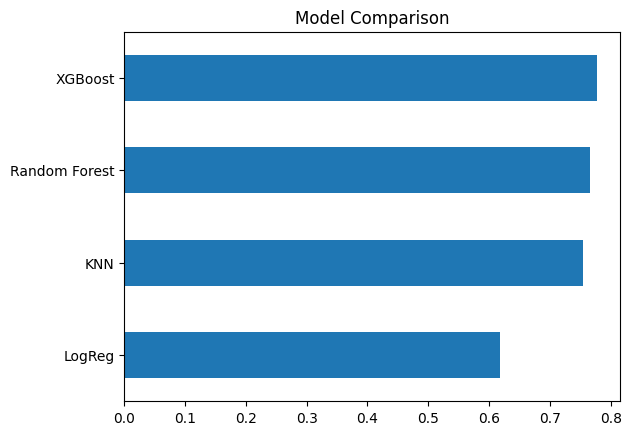

In [44]:
results = {}

for name, pipe, yt, yp in [
    ('KNN',           knn_pipe, y_test, y_pred),
    ('Random Forest', rf_pipe,  y_test, y_pred_rf),
    ('LogReg',        lr_pipe,  y_test, y_pred_lr),
    ('XGBoost',       xgb_pipe, y_test, y_pred_xgb),
]:
    results[name] = accuracy_score(yt, yp)

pd.Series(results).sort_values().plot(kind='barh', title='Model Comparison')

### 9-Parameter Tuning
Parameter tuning is the process of finding the optimal hyperparameters for a model — 
values that control the learning process but aren't learned from data (e.g., `n_neighbors`, `weights`).
It matters because the default values rarely give the best performance, and wrong values 
can cause underfitting or overfitting. GridSearchCV automates this by exhaustively trying 
all combinations and selecting the best via cross-validation.

In [45]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'knn__n_neighbors': [3, 5, 9],
#     'knn__weights': ['uniform', 'distance'],
# }

# grid_search = GridSearchCV(
#     knn_pipe, param_grid,
#     cv=3, scoring='accuracy',
#     n_jobs=-1, verbose=1
# )

# grid_search.fit(X_train[features], y_train)

# print("Best params:", grid_search.best_params_)
# print("Best CV accuracy:", grid_search.best_score_.round(4))

# y_pred_tuned = grid_search.predict(X_test[features])
# print(classification_report(y_test, y_pred_tuned))

In [46]:
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
    }

    pipe = Pipeline([
        ('prep', preprocessor),
        ('xgb', XGBClassifier(
            **params,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1,
        )),
    ])

    score = cross_val_score(pipe, X_train[features], y_train_enc,
                            cv=3, scoring='accuracy', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV accuracy:", round(study.best_value, 4))

best_xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBClassifier(
        **study.best_params,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
    )),
])

best_xgb_pipe.fit(X_train[features], y_train_enc)
y_pred_xgb = le.inverse_transform(best_xgb_pipe.predict(X_test[features]))

print(classification_report(y_test, y_pred_xgb))



e:\03_Career\01_Hard_Skills\01_Technical\04_Data_Science\EpsilonAI\CDSP\cdsp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 22. Best value: 0.790762: 100%|██████████| 30/30 [10:03<00:00, 20.11s/it]


Best params: {'n_estimators': 450, 'max_depth': 10, 'learning_rate': 0.07149357875676299, 'subsample': 0.8775865356472246, 'colsample_bytree': 0.9193527646149259, 'min_child_weight': 7}
Best CV accuracy: 0.7908


e:\03_Career\01_Hard_Skills\01_Technical\04_Data_Science\EpsilonAI\CDSP\cdsp\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:37:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                         precision    recall  f1-score   support

             functional       0.78      0.90      0.84      6452
functional needs repair       0.57      0.25      0.35       863
         non functional       0.83      0.74      0.79      4565

               accuracy                           0.79     11880
              macro avg       0.73      0.63      0.66     11880
           weighted avg       0.79      0.79      0.78     11880



### 10-Threshold Tuning

In [3]:
import numpy as np
from sklearn.metrics import classification_report

# ── Step 1: get probabilities ─────────────────────────────────────────────────
probs = best_xgb_pipe.predict_proba(X_test[features])   # shape (n, 3)
class_order = le.inverse_transform(model.classes_)
# e.g. ['functional', 'functional needs repair', 'non functional']
print(class_order)   # verify order before setting thresholds

# ── Step 2: define custom thresholds per class ────────────────────────────────
# Default is 0.33 for each in a 3-class problem
# Lower the 'needs repair' threshold → model labels more pumps as needing repair
thresholds = {
    'functional':                  0.45,   # raise slightly
    'functional needs repair':     0.20,   # lower → catch more minority cases
    'non functional':              0.45,   # raise slightly
}

# ── Step 3: apply thresholds ──────────────────────────────────────────────────
def predict_with_threshold(probs, class_order, thresholds):
    adjusted = probs.copy()
    for i, cls in enumerate(class_order):
        adjusted[:, i] = probs[:, i] / thresholds[cls]   # scale by inverse threshold
    return class_order[np.argmax(adjusted, axis=1)]

y_pred_tuned = predict_with_threshold(probs, class_order, thresholds)

# ── Step 4: compare ───────────────────────────────────────────────────────────
print("=== Default thresholds ===")
print(classification_report(le.inverse_transform(y_test_enc), 
                             le.inverse_transform(best_xgb_pipe.predict(X_test[features]))))

print("=== Tuned thresholds ===")
print(classification_report(le.inverse_transform(y_test_enc), y_pred_tuned))

NameError: name 'best_xgb_pipe' is not defined

In [ ]:
from sklearn.metrics import f1_score

best_threshold = 0.33
best_f1 = 0

for t in np.arange(0.10, 0.45, 0.02):
    thresholds['functional needs repair'] = t
    preds = predict_with_threshold(probs, class_order, thresholds)
    f1 = f1_score(le.inverse_transform(y_test_enc), preds,
                  labels=['functional needs repair'], average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best threshold for 'needs repair': {best_threshold:.2f}  →  F1: {best_f1:.4f}")

### 11-Validation
Validation is the process of evaluating a model on unseen data to estimate how well 
it will generalize. Without it, a model may perform perfectly on training data but 
fail on new inputs (overfitting). We use an 80/20 train-test split with `stratify=y` 
to preserve class proportions, and cross-validation inside GridSearchCV to ensure 
tuning results aren't dependent on a single split.

### 12-Feature Selection Permutation Importance (Embedded Method)
Since KNN has no built-in feature importances, we use Permutation Importance:
it measures how much accuracy drops when each feature's values are randomly shuffled.
A large drop means the model relied heavily on that feature a small drop means it's
less useful or redundant. This acts as an embedded selection method tied directly to
model performance.

<Axes: title={'center': 'Feature Importances (Permutation)'}>

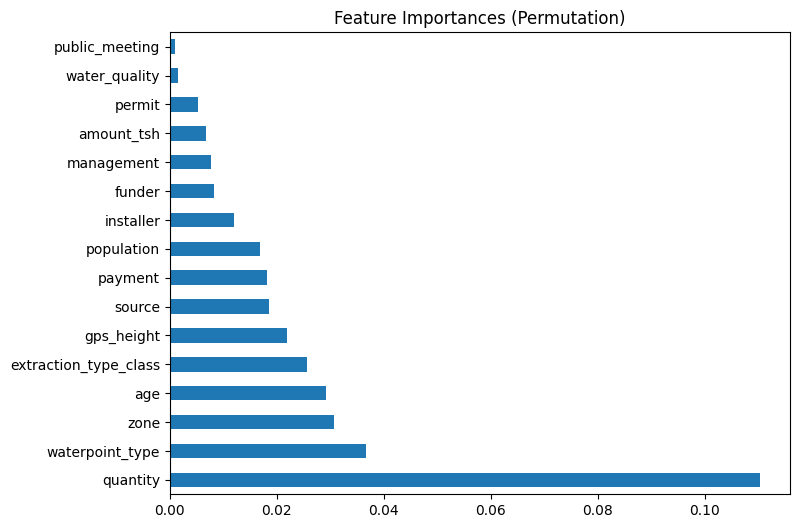

In [49]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_xgb_pipe, X_test[features], y_test_enc,
    n_repeats=3, random_state=42, n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=features).sort_values(ascending=False)

importances.plot(kind='barh', figsize=(8, 6), title='Feature Importances (Permutation)')

In [50]:
df_training.to_csv('training_data.csv',index=False)

In [51]:
import joblib

# joblib.dump(grid_search.best_estimator_, 'best_model.pkl')
# joblib.dump(kmeans, 'kmeans_zones.pkl')
joblib.dump(zone_names, 'zone_names.pkl')
joblib.dump(best_xgb_pipe, 'best_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

### 13-Deployment

In [ ]:
import streamlit as st

In [1]:
%%writefile pump_app.py 

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import reverse_geocoder as rg

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Tanzania Water Pump Predictor",
    page_icon="💧",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Global CSS ────────────────────────────────────────────────────────────────
st.markdown("""
<style>
  /* ── Font & base ── */
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap');
  html, body, [class*="css"] { font-family: 'Inter', sans-serif; }

  /* ── Hero banner ── */
  .hero {
    background: linear-gradient(135deg, #065A82 0%, #1C7293 60%, #028090 100%);
    border-radius: 16px;
    padding: 2.5rem 2rem 2rem 2rem;
    color: white;
    text-align: center;
    margin-bottom: 1.5rem;
  }
  .hero h1 { font-size: 2.4rem; font-weight: 700; margin: 0; letter-spacing: -0.5px; }
  .hero p  { font-size: 1.05rem; color: #A8DAEC; margin-top: 0.4rem; }
  .hero .badge {
    display: inline-block;
    background: #02C39A;
    color: #021C2E;
    font-weight: 700;
    font-size: 0.78rem;
    padding: 3px 12px;
    border-radius: 20px;
    margin-bottom: 0.8rem;
    letter-spacing: 1px;
    text-transform: uppercase;
  }

  /* ── Stat cards row ── */
  .cards-row { display: flex; gap: 1rem; margin-bottom: 1.5rem; flex-wrap: wrap; }
  .stat-card {
    flex: 1; min-width: 140px;
    background: white;
    border-radius: 12px;
    padding: 1.1rem 1rem;
    text-align: center;
    box-shadow: 0 2px 8px rgba(6,90,130,0.10);
    border-top: 4px solid #065A82;
  }
  .stat-card .num  { font-size: 1.9rem; font-weight: 700; color: #065A82; }
  .stat-card .lbl  { font-size: 0.78rem; color: #6B8FA8; margin-top: 2px; }

  /* ── Result box ── */
  .result-box {
    border-radius: 14px;
    padding: 1.8rem;
    text-align: center;
    margin: 1rem 0;
    box-shadow: 0 4px 16px rgba(0,0,0,0.10);
  }
  .result-box h2 { font-size: 1.7rem; font-weight: 700; margin: 0; }
  .result-box p  { margin: 0.3rem 0 0 0; font-size: 0.95rem; }
  .functional     { background: #E6F9F3; border: 2px solid #02C39A; color: #016B52; }
  .non_functional { background: #FEE9E9; border: 2px solid #F96167; color: #8B1A1A; }
  .needs_repair   { background: #FEF9E6; border: 2px solid #F9C74F; color: #7A5C00; }

  /* ── Section header ── */
  .section-header {
    font-size: 1.05rem; font-weight: 700;
    color: #065A82; margin: 1.2rem 0 0.5rem 0;
    border-left: 4px solid #02C39A;
    padding-left: 0.6rem;
  }

  /* ── Sidebar ── */
  [data-testid="stSidebar"] { background: #F0F7FC; }
  [data-testid="stSidebar"] h2 { color: #065A82; }

  /* ── Hide Streamlit branding ── */
  #MainMenu, footer { visibility: hidden; }
</style>
""", unsafe_allow_html=True)


# ── Cached loaders ────────────────────────────────────────────────────────────
@st.cache_resource
def load_model():
    return joblib.load('best_model.pkl')

@st.cache_resource
def load_encoder():
    return joblib.load('label_encoder.pkl')

@st.cache_data
def load_zone_names():
    return sorted(joblib.load('zone_names.pkl'))

@st.cache_data
def get_zone_from_coords(lat, lon):
    result = rg.search([(lat, lon)], mode=1)[0]
    return result['admin1'] or 'Unknown'

model      = load_model()
le         = load_encoder()
zone_names = load_zone_names()


# ── Hero section ──────────────────────────────────────────────────────────────
st.markdown("""
<div class="hero">
  <div class="badge">EpsilonAI · CDSP Final Project</div>
  <h1>💧 Tanzania Water Pump Predictor</h1>
  <p>Predict whether a water pump is <b>Functional</b>, <b>Non-Functional</b>, or <b>Needs Repair</b> using machine learning.</p>
</div>
""", unsafe_allow_html=True)

# ── Dataset stats row ─────────────────────────────────────────────────────────
st.markdown("""
<div class="cards-row">
  <div class="stat-card"><div class="num">59,400</div><div class="lbl">Pumps in Dataset</div></div>
  <div class="stat-card"><div class="num">16</div><div class="lbl">Features Used</div></div>
  <div class="stat-card"><div class="num">3</div><div class="lbl">Status Classes</div></div>
  <div class="stat-card"><div class="num">~82%</div><div class="lbl">Model Accuracy</div></div>
  <div class="stat-card"><div class="num">XGBoost</div><div class="lbl">Algorithm</div></div>
</div>
""", unsafe_allow_html=True)

# ── Layout: inputs left, results right ───────────────────────────────────────
col_input, col_result = st.columns([1.1, 1], gap="large")

with col_input:
    st.image(
        "images/pump.png",
        caption="Typical Tanzanian hand pump",
        use_container_width=True,
    )

# ── Sidebar inputs ────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## ⚙️ Pump Details")
    st.caption("Fill in the pump characteristics to get a prediction.")

    st.markdown('<div class="section-header">Water Characteristics</div>', unsafe_allow_html=True)
    quantity       = st.selectbox("Water Quantity",    ["enough","insufficient","dry","seasonal","unknown"])
    water_quality  = st.selectbox("Water Quality",     ["soft","salty","milky","coloured","fluoride","unknown","salty abandoned"])
    source         = st.selectbox("Water Source",      ["spring","rainwater harvesting","dam","machine dbh","shallow well","river","lake","other"])

    st.markdown('<div class="section-header">Pump Info</div>', unsafe_allow_html=True)
    waterpoint_type        = st.selectbox("Waterpoint Type",      ["communal standpipe","hand pump","other","communal standpipe multiple","improved spring","cattle trough","dam"])
    extraction_type_class  = st.selectbox("Extraction Type",      ["gravity","handpump","submersible","motorpump","rope pump","wind-powered","other"])
    payment                = st.selectbox("Payment Method",        ["never pay","per bucket","monthly","on failure","annually","unknown","other"])
    management             = st.selectbox("Management",            ["vwc","wug","water authority","wua","water board","parastatal","private operator","company","other","unknown"])

    st.markdown('<div class="section-header">Organisation</div>', unsafe_allow_html=True)
    funder    = st.selectbox("Funder",    ["government of tanzania","danida","hesawa","rwssp","world bank","kkkt","world vision","unicef","netherlands","dhv","other"])
    installer = st.selectbox("Installer", ["dwe","government","rwe","commu","danida","hesawa","kkkt","world vision","rc church","tcrs","other"])
    permit         = st.selectbox("Permit",               ["Yes","No"])
    public_meeting = st.selectbox("Public Meeting Held",  ["Yes","No"])

    st.markdown('<div class="section-header">Location & Age</div>', unsafe_allow_html=True)
    use_coords = st.toggle("Use GPS coordinates for zone", value=False)

    if use_coords:
        latitude  = st.number_input("Latitude",  min_value=-12.0, max_value=-1.0,  value=-6.0, step=0.01)
        longitude = st.number_input("Longitude", min_value=29.0,  max_value=41.0,  value=35.0, step=0.01)
        zone = get_zone_from_coords(latitude, longitude)
        st.success(f"📍 Detected zone: **{zone}**")
    else:
        zone = st.selectbox("Zone (Region)", zone_names)

    gps_height  = st.number_input("GPS Height (m)",      min_value=0,    max_value=3000,   value=500)
    population  = st.number_input("Population Nearby",   min_value=0,    max_value=30000,  value=200)
    amount_tsh  = st.number_input("Amount TSH (fee)",    min_value=0.0,  max_value=500000.0, value=0.0)
    age         = st.slider("Pump Age (years)",          min_value=0,    max_value=60,     value=10)

    predict_btn = st.button("🔍 Predict Pump Status", use_container_width=True, type="primary")


# ── Prediction ────────────────────────────────────────────────────────────────
with col_result:
    if predict_btn:
        input_df = pd.DataFrame([{
            'quantity':              quantity,
            'waterpoint_type':       waterpoint_type,
            'extraction_type_class': extraction_type_class,
            'payment':               payment,
            'water_quality':         water_quality,
            'source':                source,
            'gps_height':            gps_height,
            'population':            population,
            'management':            management,
            'funder':                funder,
            'installer':             installer,
            'permit':                int(permit == 'Yes'),
            'public_meeting':        int(public_meeting == 'Yes'),
            'amount_tsh':            amount_tsh,
            'zone':                  zone,
            'age':                   age,
        }])

        pred_enc   = model.predict(input_df)[0]
        prediction = le.inverse_transform([pred_enc])[0]
        probs      = model.predict_proba(input_df)[0]
        classes    = le.inverse_transform(model.classes_)

        # Result box
        css_class = prediction.replace(' ', '_')
        icons = {'functional': '🟢', 'non functional': '🔴', 'functional needs repair': '🟡'}
        icon  = icons.get(prediction, '⚪')

        st.markdown(f"""
        <div class="result-box {css_class}">
          <h2>{icon} {prediction.title()}</h2>
          <p>Zone detected: <b>{zone}</b></p>
        </div>
        """, unsafe_allow_html=True)

        # Probability bars
        st.markdown('<div class="section-header">Prediction Confidence</div>', unsafe_allow_html=True)
        prob_df = pd.DataFrame({'Status': classes, 'Probability': probs}) \
                    .sort_values('Probability', ascending=False)
        st.dataframe(
            prob_df.style
                .format({'Probability': '{:.1%}'})
                .bar(subset=['Probability'], color='#1C7293'),
            hide_index=True,
            use_container_width=True,
        )

        # Input summary
        st.markdown('<div class="section-header">Input Summary</div>', unsafe_allow_html=True)
        st.dataframe(input_df.T.rename(columns={0: 'Value'}), use_container_width=True)

    else:
        st.markdown("""
        <div style="background:#F0F7FC; border-radius:14px; padding:2rem; text-align:center; color:#4A7A96; margin-top:1rem;">
          <div style="font-size:3rem;">💧</div>
          <h3 style="color:#065A82;">Ready to Predict</h3>
          <p>Fill in the pump details on the left sidebar and click <b>Predict Pump Status</b>.</p>
        </div>
        """, unsafe_allow_html=True)

        st.image(
            "images/tanzania_map.png",
            caption="Tanzania — 59,400 pumps mapped across the country",
            use_container_width=True,
        )

Overwriting pump_app.py


In [2]:
! streamlit run pump_app.py

^C
